In [27]:
# load kpk_enineerin_programs.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('kpk_engineering_programs.csv')

# print the first 10 rows of the DataFrame
print(df.head(10))

                                             Program  PEC_Level  \
0          University of Swat - Chemical Engineering          1   
1    Pak-Austria Fachhochschule - Mining Engineering          3   
2  City University Peshawar - Electrical Engineering          3   
3             CECOS University - Telecom Engineering          2   
4                   UEAS Swat - Software Engineering          2   
5            Gomal University - Computer Engineering          1   
6           Sarhad University - Chemical Engineering          2   
7  City University Peshawar - Electronics Enginee...          2   
8            Qurtuba University - Mining Engineering          3   
9                UET Peshawar - Chemical Engineering          3   

   Research_Output  Student_Faculty_Ratio  PhD_Percentage  Program_Diversity  \
0             4.22                   12.4            28.5                  2   
1             3.85                   11.1            56.0                  6   
2             1.08    

In [9]:
# print coloums name

print(df.columns)

Index(['Program', 'PEC_Level', 'Research_Output', 'Student_Faculty_Ratio',
       'PhD_Percentage', 'Program_Diversity', 'University_Age',
       'Location_Type', 'Industry_Linkages', 'Employability_Rate'],
      dtype='str')


## Tas 1

In [28]:
# Multiple linear regression
# calculate R² of simple regression 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd


# simple regression
X = df[['Research_Output']]
y = df['Employability_Rate']

simple_model = LinearRegression()
simple_model.fit(X,y)

y_pred = simple_model.predict(X)

r2 = r2_score(y,y_pred)
print(r2)

0.013270372434122546


## Task 2

In [29]:
X_mul = df[['PEC_Level','Research_Output','Student_Faculty_Ratio',
        'PhD_Percentage','Program_Diversity','University_Age',
        'Location_Type','Industry_Linkages']]

y = df['Employability_Rate']

model = LinearRegression()
model.fit(X_mul,y)

y_pred_mul = model.predict(X_mul)

r2 = r2_score(y,y_pred_mul)
print(r2)

0.4292043448932331


## Task 3

In [31]:


# Get coefficients
coefficients = pd.DataFrame({
    'Feature': X_mul.columns,
    'Coefficient': model.coef_
})

# Sort by coefficient descending
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print("Coefficients:\n", coefficients)
print("\nFeature with largest positive coefficient:", coefficients.iloc[0]['Feature'])

Coefficients:
                  Feature  Coefficient
1        Research_Output     0.345798
4      Program_Diversity     0.338236
7      Industry_Linkages     0.301211
3         PhD_Percentage     0.120481
5         University_Age     0.106988
2  Student_Faculty_Ratio    -0.219006
6          Location_Type    -0.781479
0              PEC_Level    -1.229408

Feature with largest positive coefficient: Research_Output


In [32]:
# Extract the feature row for UET Peshawar - Civil Engineering
program_row = df[df['Program'] == 'UET Peshawar - Civil Engineering'][X_mul.columns]

# Predict employability
predicted_employability = model.predict(program_row)
predicted_employability[0]

np.float64(42.75082575663824)

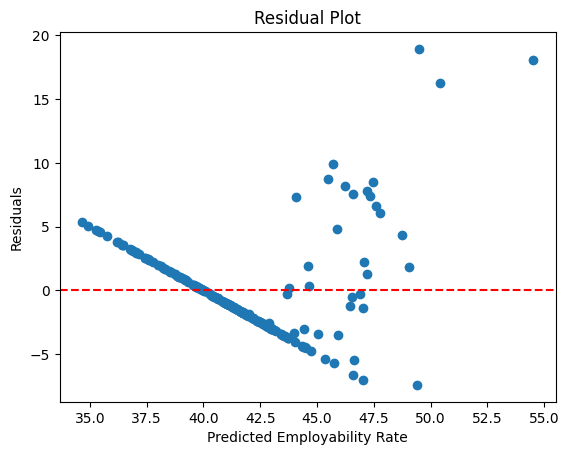

In [25]:
import matplotlib.pyplot as plt

# Residuals
residuals = y - y_pred_mul

# Residual vs Predicted plot
plt.scatter(y_pred_mul, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Employability Rate")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [33]:
from sklearn.metrics import mean_squared_error

# MSE for simple and multiple regression
mse_simple = mean_squared_error(y, y_pred)
mse_multiple = mean_squared_error(y, y_pred_mul)

# Improvement percentage
mse_improvement_percent = ((mse_simple - mse_multiple) / mse_simple) * 100
mse_improvement_percent

42.15278034015873